In [2]:
import pandas as pd

# For the Natural Breaks
import jenkspy 

# For Histogram
import matplotlib.pyplot as plt

In [3]:
# 1. Loading data
fire_14_23 = pd.read_csv("../data/processed/fire_14_23.csv", sep = ",")
print("Data loaded successfully")

Data loaded successfully


In [4]:
# 2. Creating classes for size
data = fire_14_23['size_ha']

# Calculate Natural Breaks (Jenks)
breaks = jenkspy.jenks_breaks(data, n_classes=5)

# Creating labels for the 5 classes
labels = [
    "Very small",
    "Small",
    "Medium",
    "Large",
    "Extremely large"
]

# Create classes
classes = pd.cut(fire_14_23['size_ha'], bins=breaks, include_lowest=True) 

# Count number of fires per class
table = classes.value_counts().sort_index()

# Convert to DataFrame
table = table.reset_index()

# Add column for the size names using the labels
table['size'] = labels

# Order and print table
table.columns = ['class intervals (ha)', 'number of fires', 'size']
table = table[['size', 'class intervals (ha)', 'number of fires']] # reorder the table so that size is first

table

,size,class intervals (ha),number of fires
0,Very small,"(199.999, 23677.9]",3892
1,Small,"(23677.9, 92412.0]",249
2,Medium,"(92412.0, 215280.41]",49
3,Large,"(215280.41, 430000.0]",17
4,Extremely large,"(430000.0, 885388.214]",8


In [5]:
# 3. Adding the labels to the copy csv of fire_14_23
fire_tot = fire_14_23.copy()

fire_tot['size'] = pd.cut(
    fire_tot['size_ha'],
    bins = breaks,
    labels = labels,
    include_lowest = True
)

display(fire_tot.head(5))

,province,fire_id,latitude,longitude,year,size_ha,cause,size
0,Alberta,HWF175,57.552983,-115.553983,2023,251.80000,Unknown,Very small
1,Saskatchewan,23SR-LLHIR03,58.182064,-103.050880,2023,214.70000,Natural,Very small
2,Quebec,20231080689,50.571300,-79.304600,2023,19248.49051,Natural,Very small
3,Saskatchewan,23LA-HARDY,55.622898,-106.395540,2023,314.00000,Natural,Very small
4,Saskatchewan,23BN-LINVALL,56.361978,-109.013426,2023,660.00000,Natural,Very small


In [6]:
# 4. Exporting
fire_tot.to_csv("../data/processed/fire_tot.csv", index = False)
print("Export fire_tot successful")

# Exporting the fire data of 2014 - 2018 as new csv
wildfire_14_18 = fire_tot[
    (fire_tot["year"] >= 2014) & 
    (fire_tot["year"] <= 2018)
].copy()

wildfire_14_18.to_csv("../data/processed/wildfire_map/wildfire_14_18.csv", index = False)
print("Export wildfire_14_18 successful")

# Exporting the fire data of 2019 - 2023
wildfire_19_23 = fire_tot[
    (fire_tot["year"] >= 2019) & 
    (fire_tot["year"] <= 2023)
].copy()

wildfire_19_23.to_csv("../data/processed/wildfire_map/wildfire_19_23.csv", index = False)
print("Export wildfire_19_23 successful")

Export fire_tot successful
Export wildfire_14_18 successful
Export wildfire_19_23 successful


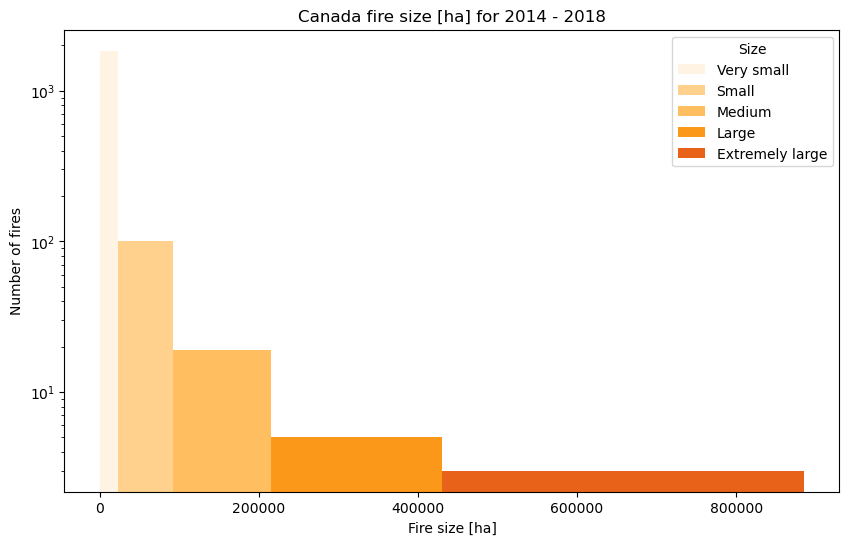

<Figure size 640x480 with 0 Axes>

In [13]:
# 3. Histogram for 2014 - 2018
histo_14_18 = wildfire_14_18['size_ha']

# Colors for each class
colors = [
    "#fff3e0",
    "#ffcc80",
    "#ffb74d",
    "#fb8c00",
    "#e65100"
]

# Create figure
plt.figure(figsize=(10,6))

# Plot each class separately
for i in range(len(breaks)-1):

    class_data = histo_14_18[
        (histo_14_18 >= breaks[i]) &
        (histo_14_18 <= breaks[i+1])
    ]

    plt.hist(
        class_data,
        bins=[breaks[i], breaks[i+1]],
        color=colors[i],
        alpha=0.9,
        label=labels[i]
    )

# logarithmische y-Achse
plt.yscale('log')

# Labels
plt.xlabel('Fire size [ha]')
plt.ylabel('Number of fires')
plt.title('Canada fire size [ha] for 2014 - 2018')
plt.legend(title = 'Size')

# Show plot
plt.show()

# Save figure
plt.savefig("../outputs/histogram_2014_2018.png")

In [9]:
# 4. Table for 2014 - 2018

table_14_18 = (wildfire_14_18['size'].value_counts().reset_index())

table_14_18.columns = ['size', 'number of fires']

table_14_18

,size,number of fires
0,Very small,1841
1,Small,100
2,Medium,18
3,Large,5
4,Extremely large,3


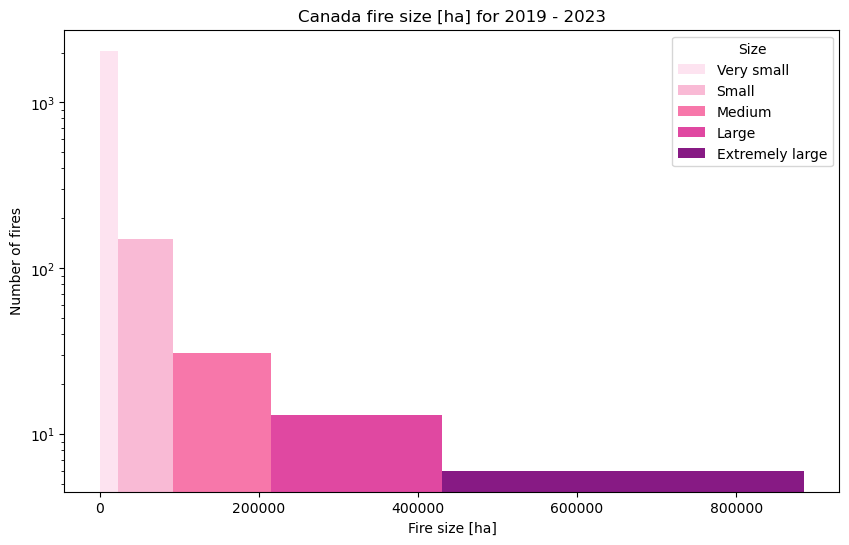

<Figure size 640x480 with 0 Axes>

In [14]:
# 5. Histogram for 2019 - 2023

# Years 2019-2023
histo_19_23 = wildfire_19_23['size_ha']

# Colors for each class
colors = [
    "#fde0ef",
    "#f9b3d1",
    "#f768a1",
    "#dd3497",
    "#7a0177"
]

# Create figure
plt.figure(figsize=(10,6))

# Plot each class separately
for i in range(len(breaks)-1):

    class_data = histo_19_23[
        (histo_19_23 >= breaks[i]) &
        (histo_19_23 <= breaks[i+1])
    ]

    plt.hist(
        class_data,
        bins=[breaks[i], breaks[i+1]],
        color=colors[i],
        alpha=0.9,
        label=labels[i]
    )

# logarithmische y-Achse
plt.yscale('log')

# Labels
plt.xlabel('Fire size [ha]')
plt.ylabel('Number of fires')
plt.title('Canada fire size [ha] for 2019 - 2023')
plt.legend(title = 'Size')

# Show plot
plt.show()

# Save figure
plt.savefig("../outputs/histogram_2019_2023.png")

In [15]:
# 6. Table for 2014 - 2023

table_19_23 = (wildfire_19_23['size'].value_counts().reset_index())

table_19_23.columns = ['size', 'number of fires']

table_19_23

,size,number of fires
0,Very small,2051
1,Small,149
2,Medium,31
3,Large,12
4,Extremely large,5
